In [1]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
import hashlib

import wandb
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sys.path.append(os.path.abspath(".."))

from src.utils.get_trainer import get_trainer
from src.utils.logging import WandbLogger
from src.utils.telegram import send_message

# Create OOF and Test pred

In [2]:
# ===== User config =====
load_dotenv(dotenv_path="../.env")

model_name = "xgb"
data_id = "023"

n_trial = 57
n_custom = None

In [3]:
# === get params, n_fold, seed, and batch_rows ===
study_name = f"{model_name}-{data_id}"
feature_dir = Path(f"../artifacts/features/base/{data_id}")

if n_trial is not None and n_custom is not None:
    raise ValueError("Set either n_trial or custom_params_json (not both).")
if n_trial is not None:
    params_id = f"trl{n_trial}"
    params_path = f"../artifacts/params/{study_name}/{params_id}.json"
elif n_custom is not None:
    params_id = f"cus{n_custom}"
    params_path = f"../artifacts/params/custom/{params_id}.json"
else:
    raise ValueError("Set n_trial or custom_params_json.")

with open(params_path, "r") as f:
    manifest = json.load(f)

params = manifest["params"]
n_fold = manifest["n_fold"]
seed = manifest["seed"]
batch_rows = manifest["batch_rows"]
opts = manifest["opts"]

print("Manifest path: ", params_path)
print("Params:\n", params)
print("n_fold: ", n_fold)
print("seed: ", seed)
print("batch_rows: ", batch_rows)
print("opts: ", opts)

Manifest path:  ../artifacts/params/xgb-023/trl57.json
Params:
 {'learning_rate': 0.02, 'max_depth': 12, 'min_child_weight': 55.88508982574673, 'colsample_bytree': 0.3230413431876774, 'subsample': 0.8952457988991019, 'reg_alpha': 0.8895194204185932, 'reg_lambda': 1.0256503696905537}
n_fold:  5
seed:  42
batch_rows:  1000000
opts:  {}


In [4]:
# === WANDB ===
wandb_project = os.environ.get("COMPETITION_NAME")
wandb.login(key=os.environ.get("WANDB_API_KEY"))

run = wandb.init(
    project=wandb_project,
    group=study_name,
    name=params_id,
    config={
        "data_id": data_id,
        "n_fold": n_fold,
        "seed": seed,
        "batch_rows": batch_rows,
        **params,
        **opts
    },
    tags=[model_name, "oof"]
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/hanse/.netrc
wandb: Currently logged in as: kaitookano (kaitookano-waseda-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
# === Training ===
trainer_class = get_trainer(model_name)
trainer = trainer_class(
    data_id,
    feature_dir,
    features=None,
    target="target",
    fold_col=None,
    weight_col=None,
    cat_cols=None,
    params=params,
    n_fold=n_fold,
    seed=seed,
    batch_rows=batch_rows,
    use_cudf=True,
    opts=opts
)

result = trainer.fit(
    loggers=[WandbLogger(run=run)]
)

CATS: 0 columns
Fold Col: 5fold-s42
===== Fold 1 / 5 =====
Avail Mem: 18.46 GB
[0]	train-auc:0.96515	eval-auc:0.96373
[100]	train-auc:0.97623	eval-auc:0.97341
[200]	train-auc:0.97851	eval-auc:0.97469
[300]	train-auc:0.98017	eval-auc:0.97538
[400]	train-auc:0.98145	eval-auc:0.97581
[500]	train-auc:0.98258	eval-auc:0.97604
[600]	train-auc:0.98353	eval-auc:0.97619
[700]	train-auc:0.98449	eval-auc:0.97629
[800]	train-auc:0.98529	eval-auc:0.97636
[900]	train-auc:0.98603	eval-auc:0.97642
[1000]	train-auc:0.98671	eval-auc:0.97648
[1100]	train-auc:0.98735	eval-auc:0.97651
[1200]	train-auc:0.98798	eval-auc:0.97653
[1300]	train-auc:0.98855	eval-auc:0.97656


In [ ]:
# ===== Save Manifest, OOF, and Test pred=====
runs_root = Path("../runs")
run_id = f"{model_name}-{data_id}-{params_id}-s{seed}"
run_dir = runs_root / run_id
run_dir.mkdir(parents=True, exist_ok=True)

s = json.dumps(params, sort_keys=True, separators=(",", ":"), ensure_ascii=False)
phash = hashlib.sha256(s.encode()).hexdigest()[:10]

manifest = {
    "run_id": run_id,
    "wandb_id": run.id,
    "wandb_url": run.url,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model_name": model_name,
    "data_id": data_id,
    "n_fold": n_fold,
    "seed": seed,
    "batch_rows": batch_rows,
    "feature_dir": str(feature_dir.resolve()),
    "phash": phash,
    "param_source": params_path,
    "params": params,
    "run_dir": str(run_dir.resolve()),
    "cv_score": result.oof_score,
    "submission": {
        "competition": None,
        "ref": None,
        "file": None,
        "public_score": None,
        "private_score": None,
        "submitted_at": None
    }
}

with open(run_dir / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=4)

print("manifest saved", run_dir / "manifest.json")

# oof and test pred
np.save(run_dir / "oof.npy", result.oof)
np.save(run_dir / "test.npy", result.test_pred)

print(f"oof and test preds saved successfully in:\n{run_dir}")
send_message(
    f"✅ Finished CV for {run_id}!"
    f"\nScore: {round(result.oof_score, 5)}"
)

# Check Feature Importance (Only XGB)

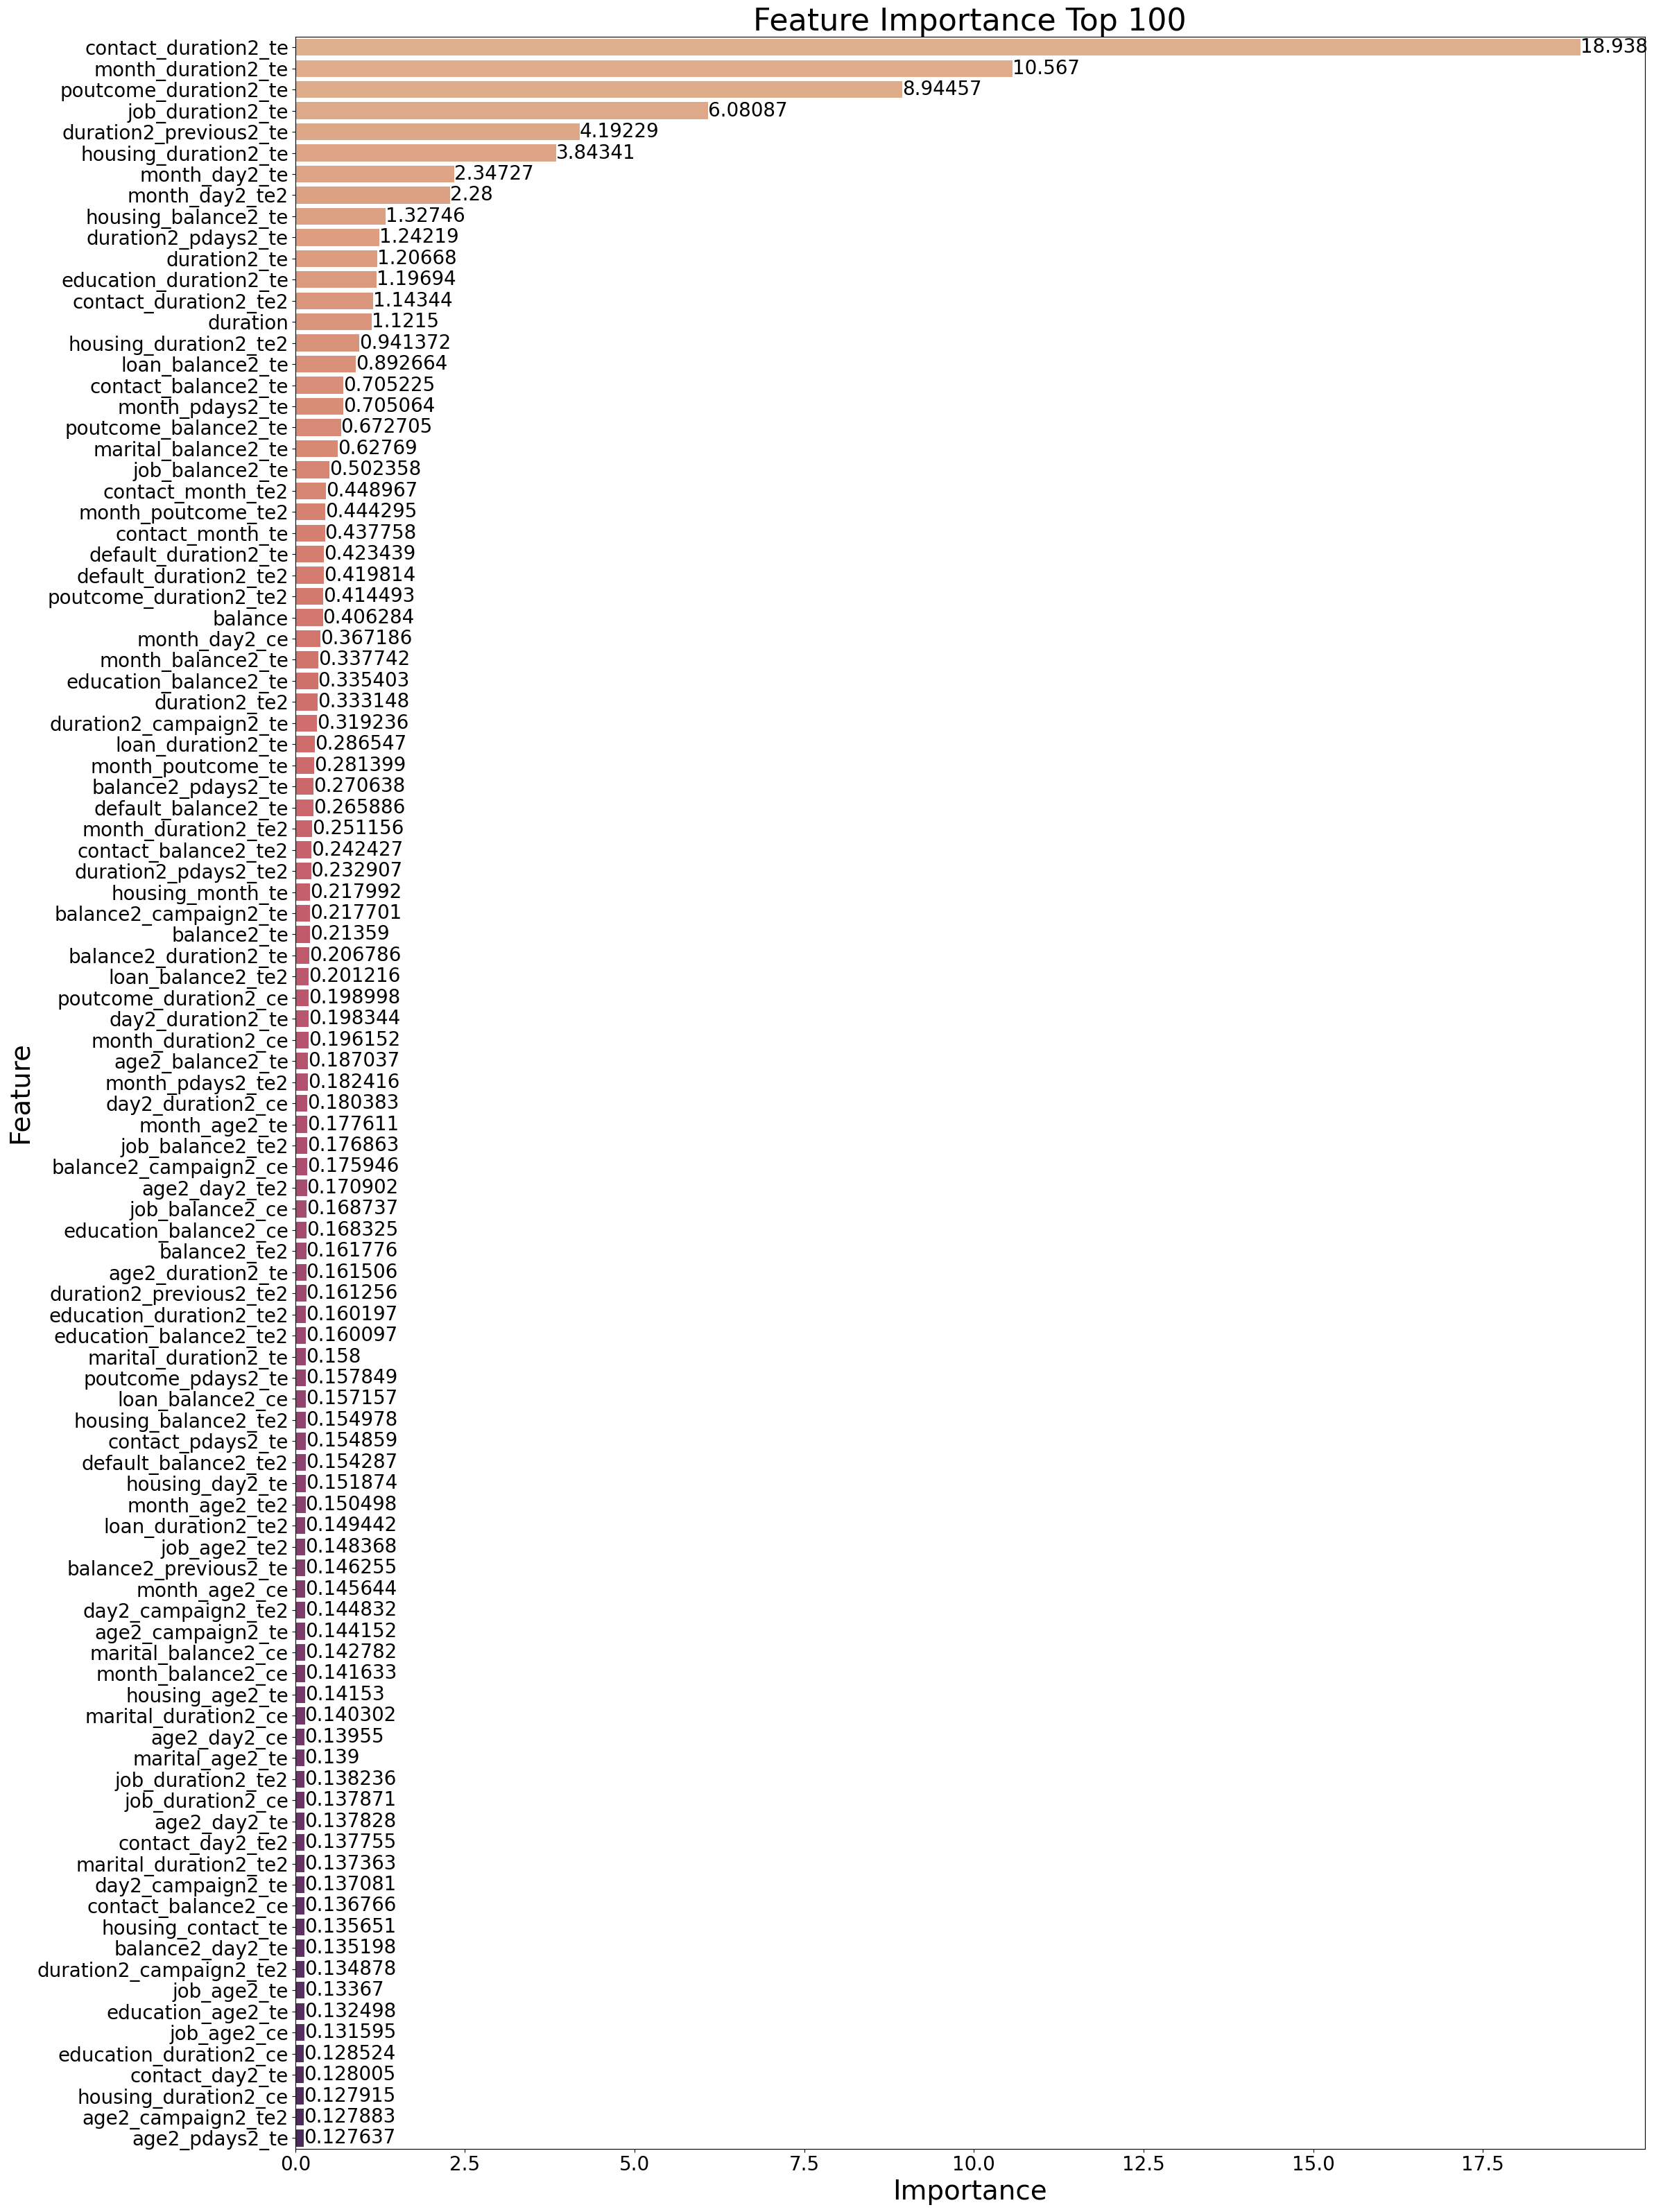

FI graph saved successfully to ../runs/xgb-023-trl44-s42


In [7]:
# Plot feature importance and get top columns
df = result.fi_mean.to_pandas()
df_top100 = df[:100]

fig, ax = plt.subplots(figsize=(24, 32))
sns.barplot(
    data=df_top100,
    y="Feature",
    x="mean_ratio",
    orient="h",
    palette="flare",
    hue="Feature",
    ax=ax
)
for container in ax.containers:
    labels = ax.bar_label(container)
    for label in labels:
        label.set_fontsize(20)
plt.title("Feature Importance Top 100", fontsize=32)
plt.xlabel("Importance", fontsize=28)
plt.ylabel("Feature", fontsize=28)
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)
plt.tight_layout()

fig.savefig(run_dir / "feature_importance.png", dpi=200, bbox_inches="tight")
fig.savefig(run_dir / "feature_importance.svg", bbox_inches="tight")

plt.show()

print(f"FI graph saved successfully to {run_dir}")

In [9]:
thresholds = [0.90, 0.95, 0.99]       # しきい値リスト
total = df["mean_ratio"].sum()

for th in thresholds:
    limit = th * total                # このしきい値に対応する累積比率

    # 累積と K を計算（「閾値を超える要素も1つ含める」ロジック）
    cum = df["mean_ratio"].cumsum()
    k = int((cum <= limit).sum())
    if k < len(df):
        k += 1

    drop_cols = df["Feature"].iloc[k:].tolist()
    print(f"Threshold {th:.2f} → Drop {len(drop_cols)} cols")

    # ファイル名を動的に決定
    path = run_dir / f"drop_cols_{int(th*100)}.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump(drop_cols, f, ensure_ascii=False, indent=4)
    print(f"saved: {path}")

N  Drop Cols: 109
['default_month_ce', 'job_previous2_ce', 'poutcome_pdays2_ce', 'loan_contact_te2', 'loan_previous2_te', 'contact_previous2_te', 'marital_loan_ce', 'loan_te', 'default_loan_te', 'housing_te', 'housing_campaign2_ce', 'job_poutcome_te2', 'default_housing_te', 'pdays2_te2', 'education_pdays2_ce', 'housing_loan_te2', 'default_contact_te', 'contact_te', 'education_poutcome_ce', 'default_poutcome_te', 'marital_education_te2', 'pdays2_previous2_ce', 'job_ce', 'pdays2_previous2_te2', 'education_housing_ce', 'campaign2_previous2_ce', 'default_pdays2_te2', 'job_default_ce', 'contact_pdays2_ce', 'previous2_te', 'loan_month_te2', 'poutcome_previous2_te', 'loan_pdays2_ce', 'default_campaign2_te2', 'housing_pdays2_ce', 'housing_contact_ce', 'marital_housing_ce', 'pdays_ce', 'default_previous2_te', 'contact_poutcome_ce', 'marital_contact_ce', 'month_te2', 'campaign2_previous2_te2', 'education_housing_te2', 'marital_housing_te2', 'marital_poutcome_ce', 'education_previous2_ce', 'educa